Lilian Chan, University of Guelph <br>
Arctic vector-borne disease transmission suitability model <br> <br>

Purpose: Create spatiotemporal maps and conduct time-series analyses of thermal suitability for *Setaria yehi* (mosquito-borne nematode parasite) transmission across the Canadian Arctic.

We quantified days per year exceeding two suitability thresholds using **upper credibility bounds (97.5% quantile)** of the posterior distribution:
- S(T) > 0.001: minimally suitable thermal conditions for transmission
- S(T) > 0.5: relatively high thermal suitability

We then examined temporal trends and spatial patterns across three focal regions: Cambridge Bay (Nunavut), Kugluktuk (Nunavut), and Yellowknife (Northwest Territories), analyzing time series of suitable transmission days, first/last day of transmission season, and mean summer temperature under current and future climate scenarios.


Table of content:
<ol start="0">
  <li>Set-up workspace</li>
  <li>Function for calculating suitability for transmission</li>
  <li>Download climate data</li>
  <li>Calculate suitability</li>
  <li>Spatial mapping</li>
  <li>Cambridge Bay, Kugluktuk, and Yellowknife</li>
  <li>Compared to Thomas et al. 2025</li>
</ol>
<br>
Inputs: <br>
data-processed/suitability/S.predictions.scaled.csv - posterior distribution of scaled suitability estimates <br> 
All the .nc files under data-raw/climate-data/ssp245 - current and future scenario projections <br><br>

Outputs: <br>
figures/FigS7-suitability.upper.png - Spatial maps of thermal suitability <br>

# 0. Set-up workspace

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
spkws = dict(projection = ccrs.PlateCarree(), transform = ccrs.PlateCarree())
from datetime import datetime
import datetime as dt

from siphon.catalog import TDSCatalog
#from xclim.core.calendar import convert_calendar, percentile_doy
import xclim.indicators as xci

# pysal.esda for spatial autocorrelation analysis
import esda 
import libpysal as lps

D:\anaconda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
# change working directory
os.chdir('D:/UofG/Arctic-VBD')
print(os.getcwd()) # verify change

D:\UofG\Arctic-VBD


# 1. Function for calculating suitability for transmission

In [3]:
# Load the csv file containing suitability at each temperature
suitability = pd.read_csv("data-processed/suitability/S.predictions.scaled.csv")
suitability = suitability[["temp", "scaled_lowerCI", "scaled_median", "scaled_upperCI"]]
suitability.head()

,temp,scaled_lowerCI,scaled_median,scaled_upperCI
0,0.0,0.0,0.0,0.0
1,0.1,0.0,0.0,0.0
2,0.2,0.0,0.0,0.0
3,0.3,0.0,0.0,0.0
4,0.4,0.0,0.0,0.0


In [5]:
# filter where suitability is above threshold
filtered_lower = suitability[suitability["scaled_upperCI"] > 0]
filtered_higher = suitability[suitability["scaled_upperCI"] > 0.5]

# compute temperature range
temp_min_lower = filtered_lower["temp"].min()
temp_max_lower = filtered_lower["temp"].max()
temp_min_higher = filtered_higher["temp"].min()
temp_max_higher = filtered_higher["temp"].max()

print("Temperature range where suitability > 0")
print(temp_min_lower, temp_max_lower)
print("Temperature range where suitability > 0.5:")
print(temp_min_higher, temp_max_higher)

Temperature range where suitability > 0
10.9 35.7
Temperature range where suitability > 0.5:
20.9 30.1


In [6]:
# Create an interpolation function such that the suitability of any temperature can be calculated (even if it is not in the csv file)

from scipy.interpolate import interp1d
suit_func = interp1d(suitability["temp"], suitability["scaled_upperCI"], 
                     bounds_error=False, fill_value=0)
suit_func

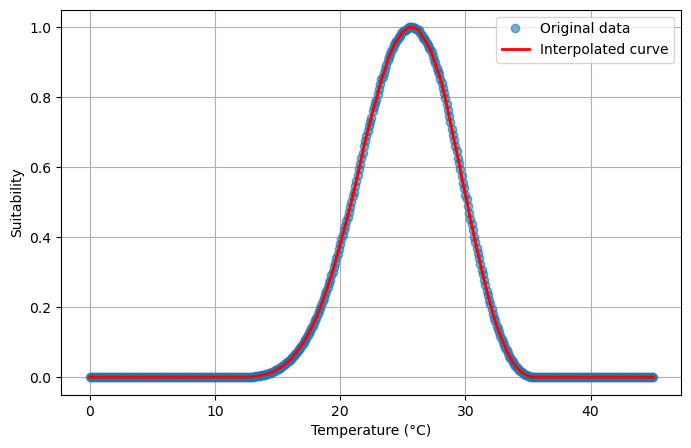

In [7]:
# Check the interpolation function
temps = np.linspace(suitability["temp"].min(), suitability["temp"].max(), 1000)

plt.figure(figsize = (8,5))
plt.plot(suitability["temp"], suitability["scaled_upperCI"], 'o', label="Original data", alpha=0.6)
plt.plot(temps, suit_func(temps), '-', label = "Interpolated curve", color='red', linewidth=2)
plt.xlabel("Temperature (°C)")
plt.ylabel("Suitability")
plt.legend()
plt.grid(True)
plt.show()

Below are some functions to calculate thermal suitability. The first function, suitability, counts the annual number of days where thermal suitability exceeds a specified threshold. The second function, suit_first_last_day, extends the suitability calculation by additionally identifying the first and last day of year when suitable conditions occur. The last function, summary, computes long-term summaries (median, mean, standard deviation, and interquartile range) across all years.

In [8]:
def suitability(data, thres = 0):
    # Calculates the annual number of days suitable for nematode transmission based 
    # on daily temperature suitability estimates. The function applies a temperature-
    # dependent suitability function (suit_func) to daily mean temperatures,then 
    # counts the number of days per year where thermal suitability exceeds a specified
    # threshold (default: S(T) > 0). 
    
    # Find suitability in each year
    S = xr.apply_ufunc(
        suit_func,
        data.tas,
        dask="parallelized",
        output_dtypes=[float])

    # Count the number of days where S > thres in each year:
    S = S.where(~np.isnan(data.tas))
    suit_days = S > thres

    # Number of suitable days
    n_days = suit_days.groupby("time.year").sum("time")
    

    # Land mask
    land_mask = ~data.tas.isel(time=0).isnull()
    n_days = n_days.where(land_mask)
    
    return xr.Dataset({
        "n_days": n_days
    })

In [9]:
def suit_first_last_day(data, thres = 0):

    # Quantifies the timing of the start and end of the transmission season by 
    # calculating three metrics of annual thermal suitability for nematode transmission.
    # The function applies a temperature-dependent suitability function (suit_func) to 
    # daily mean temperatures, then: 
    # (1) counts the annual number of days where S(T) exceeds a specified threshold, and 
    # (2) identifies the first and last day of year (day-of-year) when suitable conditions
    # occur. 
    # Returns an xarray Dataset containing three variables: 
    # n_days (annual count of suitable days), first_day (calendar day marking transmission 
    # season onset), and last_day (calendar day marking transmission season end).
    
    # Find suitability in each year
    S = xr.apply_ufunc(
        suit_func,
        data.tas,
        dask="parallelized",
        output_dtypes=[float])

    # Count the number of days where S > thres in each year:
    S = S.where(~np.isnan(data.tas))
    suit_days = S > thres

    # Number of suitable days
    n_days = suit_days.groupby("time.year").sum("time")
    
    # Find the first and last day of suitability:
    # Day of year
    doy = suit_days.time.dt.dayofyear

    # First suitable day
    first_day = doy.where(suit_days).groupby("time.year").min("time")

    # Last suitable day
    last_day = doy.where(suit_days).groupby("time.year").max("time")

    # Land mask
    land_mask = ~data.tas.isel(time=0).isnull()
    
    n_days = n_days.where(land_mask)
    first_day = first_day.where(land_mask)
    last_day = last_day.where(land_mask)
    
    return xr.Dataset({
        "n_days": n_days,
        "first_day": first_day,
        "last_day": last_day
    })

In [10]:
def summary(ds_yearly):
    
    # Computes long-term summary statistics from annual time series data. For each 
    # variable in the input dataset, the function calculates five metrics across 
    # all years: median, mean, standard deviation, and 25th and 75th percentiles. 
    
    # Returns a new xarray Dataset with summary variables named according 
    # to the original variables and metric (e.g. n_days_med, n_days_mean, n_days_std) 
    
    ds_out = xr.Dataset()

    for var in ds_yearly.data_vars:

        ds_out[f"{var}_med"] = ds_yearly[var].median("year", skipna=True)
        ds_out[f"{var}_mean"] = ds_yearly[var].mean("year")
        ds_out[f"{var}_std"] = ds_yearly[var].std("year")
        ds_out[f"{var}_q25"] = ds_yearly[var].quantile(0.25, dim="year")
        ds_out[f"{var}_q75"] = ds_yearly[var].quantile(0.75, dim="year")

    return ds_out

# 2. Download climate data (skip this if already downloaded climate data)

Here we will use a publicly available downscaled gridded data from PCIC. PCIC used observations from NRCAN gridded data from 1950 - 2005 to perform BCCAQv2 downscaling.

In [ ]:
# acquire downscaled data from PAVICS - same as section 4.4
url_pavics = "https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/datasets/"
url_downscaled = url_pavics + "simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/catalog.xml"
cat_sds = TDSCatalog(url_downscaled)

# open the downscaled gcm dataset and load the data
opendap_urls = [cat_sds.datasets[i].access_urls["OPENDAP"] for i in range(len(cat_sds.datasets))]
datasets_canesm_sds = list(filter(lambda x: 'CanESM' in x, opendap_urls))

datasets_canesm_sds

This time we will use CanESM5 ensemble member r1i1p2f1

In [ ]:
ssp245_url = datasets_canesm_sds[11] #SSP2-4.5; ensemble member: r1i1p2f1
print(ssp245_url)
ssp245_all = xr.open_dataset(ssp245_url)[['tasmax','tasmin']]

In [ ]:
# select spatial domain (all of Canada)
# lat_bnds = [41, 90]
# lon_bnds = [-143, -52]

# select spatial domain (Down to central Manitoba)
#lat_bnds = [55, 90]
#lon_bnds = [-143, -59]


# select spatial domain
#ssp245 = ssp245_all.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))
ssp245 = ssp245_all

In [ ]:
CBAY_lat = 69.1169
CBAY_lon = -105.0597

KUG_lat = 67.8252
KUG_lon = -115.0966

YKN_lat = 62.4540
YKN_lon = -114.3718

lats = [CBAY_lat,KUG_lat, YKN_lat]
lons = [CBAY_lon, KUG_lon, YKN_lon]

ssp245 = ssp245_all.sel(
    lat= lats,
    lon= lons,
    method="nearest"
)

We need daily mean temperature. However, this dataset only contains the daily maximum and daily minimum temperatures. To get the daily mean temperature, we will take the average of the daily maximum and daily minimum. Since the dataset is too large, we will subset the dataset by year and compute the mean temperature.

In [ ]:
start_year = 1950
end_year = 1980

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    # outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    outfile = f"tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 1986
end_year = 1990

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    #outfile = f"tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 1991
end_year = 1994

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    #outfile = f"tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 1995
end_year = 2025

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2026
end_year = 2027

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2030
end_year = 2060

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2065
end_year = 2066

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2067
end_year = 2069

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

In [ ]:
start_year = 2070
end_year = 2100

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

# 3. Calculate suitability

In [11]:
# select spatial domain (Down to central Manitoba)
lat_bnds = [55, 90]
lon_bnds = [-143, -59]

## Historical 1: 1950-1980

##### S(T) > 0

In [12]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 1980

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_hist1_low = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp245_hist1_low = summary(ssp245_hist1_low)

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\4174216958.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_hist1_low = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [13]:
ssp245_hist1_low

<xarray.Dataset> Size: 13MB
Dimensions:      (lon: 984, lat: 342)
Coordinates:
  * lon          (lon) float64 8kB -141.0 -140.9 -140.8 ... -59.21 -59.13 -59.04
  * lat          (lat) float64 3kB 55.04 55.12 55.21 55.29 ... 83.29 83.37 83.46
    quantile     float64 8B 0.25
Data variables:
    n_days_med   (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan
    n_days_mean  (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan
    n_days_std   (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan
    n_days_q25   (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan
    n_days_q75   (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan

##### S(T) > 0.5

In [14]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 1980

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_hist1_high = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp245_hist1_high = summary(ssp245_hist1_high)

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\223721696.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_hist1_high = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


## Historical 2: 1995-2025

##### S(T) > 0

In [15]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_hist2_low = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp245_hist2_low = summary(ssp245_hist2_low)

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\945096032.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_hist2_low = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


##### S(T) > 0.5

In [16]:
start_year = 1995
end_year = 2025

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_hist2_high = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp245_hist2_high = summary(ssp245_hist2_high)

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\1968619844.py:24: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_hist2_high = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


## Future 1: 2030-2060

##### S(T) > 0

In [17]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_future1_low = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp245_future1_low = summary(ssp245_future1_low)

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\3320897191.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_future1_low = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


##### S(T) > 0.5

In [18]:
start_year = 2030
end_year = 2060

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_future1_high = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp245_future1_high = summary(ssp245_future1_high)

Processing year 2030...
Processing year 2031...
Processing year 2032...
Processing year 2033...
Processing year 2034...
Processing year 2035...
Processing year 2036...
Processing year 2037...
Processing year 2038...
Processing year 2039...
Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\2491541172.py:24: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_future1_high = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


## Future 2: 2700-2100

##### S(T) > 0

In [19]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_future2_low = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp245_future2_low = summary(ssp245_future2_low)

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...
Processing year 2085...
Processing year 2086...
Processing year 2087...
Processing year 2088...
Processing year 2089...
Processing year 2090...
Processing year 2091...
Processing year 2092...
Processing year 2093...
Processing year 2094...
Processing year 2095...
Processing year 2096...
Processing year 2097...
Processing year 2098...
Processing year 2099...
Processing year 2100...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\2170175645.py:25: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_future2_low = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


##### S(T) > 0.5

In [20]:
start_year = 2070
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

    # Calculate suitability
    ds_year_suit = suitability(ds_year, thres = 0.5)

    # Add to the list
    suit_list.append(ds_year_suit)

    ds_year.close()

ssp245_future2_high = xr.concat(suit_list, dim="year")
# Calculate summary statistics
ssp245_future2_high = summary(ssp245_future2_high)

Processing year 2070...
Processing year 2071...
Processing year 2072...
Processing year 2073...
Processing year 2074...
Processing year 2075...
Processing year 2076...
Processing year 2077...
Processing year 2078...
Processing year 2079...
Processing year 2080...
Processing year 2081...
Processing year 2082...
Processing year 2083...
Processing year 2084...
Processing year 2085...
Processing year 2086...
Processing year 2087...
Processing year 2088...
Processing year 2089...
Processing year 2090...
Processing year 2091...
Processing year 2092...
Processing year 2093...
Processing year 2094...
Processing year 2095...
Processing year 2096...
Processing year 2097...
Processing year 2098...
Processing year 2099...
Processing year 2100...


C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\4055964662.py:24: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_future2_high = xr.concat(suit_list, dim="year")
D:\anaconda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


# 4. Spatial mapping

In [21]:
ssp245_future2_low['n_days_mean'].max()

<xarray.DataArray 'n_days_mean' ()> Size: 8B
array(182.80645161)
Coordinates:
    quantile  float64 8B 0.25
Attributes:
    units:          DegC
    standard_name:  air_temperature
    _ChunkSizes:    [1460   50   50]

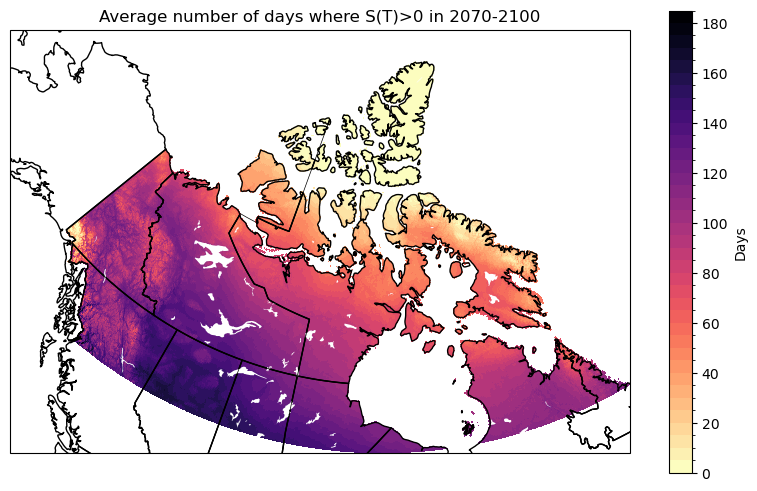

In [22]:
levels = np.arange(0, 190, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
#ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp245_future2_low["n_days_mean"].plot.pcolormesh(ax = ax, 
                                                   transform = ccrs.PlateCarree(),
                                                   levels = levels, 
                                                   cmap = 'magma_r',
                                                   cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                                  )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Average number of days where S(T)>0 in 2070-2100")

plt.show()

We will specifically look at the trends in 3 locations: Cambridge Bay, Kugluktuk, and Yellowknife

In [23]:
CBAY_lat = 69.1169
CBAY_lon = -105.0597

KUG_lat = 67.8252
KUG_lon = -115.0966

YKN_lat = 62.4540
YKN_lon = -114.3718

Plot maps that also show the three locations

In [24]:
ssp245_hist1_low = ssp245_hist1_low.drop_vars("quantile")
ssp245_hist1_high = ssp245_hist1_high .drop_vars("quantile")
ssp245_hist2_low = ssp245_hist2_low.drop_vars("quantile")
ssp245_hist2_high = ssp245_hist2_high .drop_vars("quantile")
ssp245_future1_low = ssp245_future1_low.drop_vars("quantile")
ssp245_future1_high = ssp245_future1_high .drop_vars("quantile")
ssp245_future2_low = ssp245_future2_low.drop_vars("quantile")
ssp245_future2_high = ssp245_future2_high .drop_vars("quantile")

C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\3795921134.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


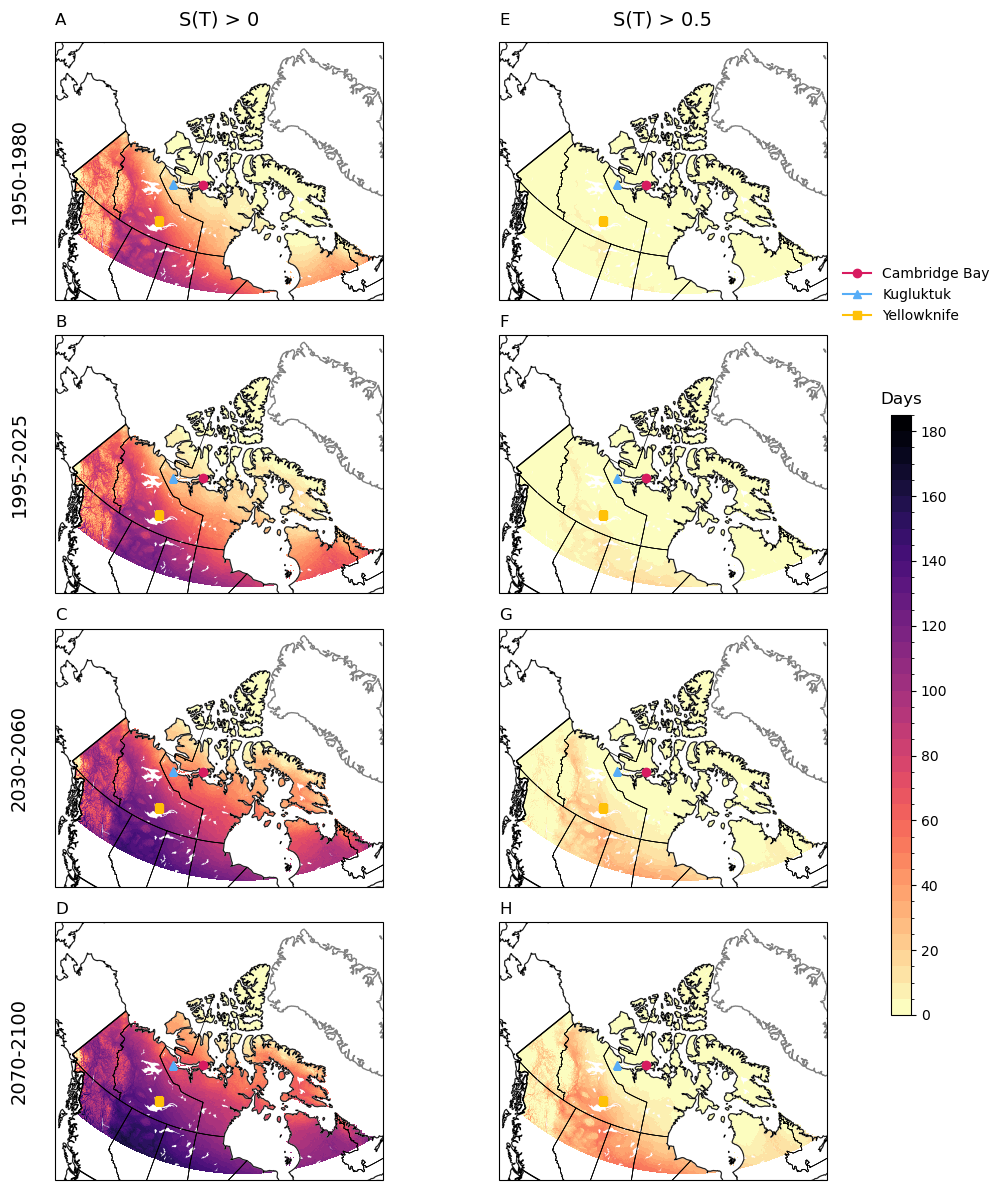

In [25]:
# plot all historical and future simulations
levels = np.arange(0, 190, 5)
cmap = 'magma_r'

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, axes = plt.subplots(nrows = 4, ncols = 2, 
                            subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)), 
                            figsize = (10,12))

# Historical 1: 1950-1980, S(T) > 0
ssp245_hist1_low["n_days_mean"].plot.pcolormesh(ax = axes[0,0], 
                                                transform = ccrs.PlateCarree(),
                                                levels = levels, 
                                                cmap = cmap,
                                                add_colorbar = False
                                               )
axes[0,0].set_title("A", loc='left')

# Historical 1: 1950-1980, S(T) > 0.5
ssp245_hist1_high["n_days_mean"].plot.pcolormesh(ax = axes[0,1], 
                                                 transform = ccrs.PlateCarree(),
                                                 levels = levels, 
                                                 cmap = cmap,
                                                 add_colorbar = False
                                                )
axes[0,1].set_title("E", loc='left')

# Historical 2: 1995-2025, S(T) > 0
ssp245_hist2_low["n_days_mean"].plot.pcolormesh(ax = axes[1,0], 
                                                transform = ccrs.PlateCarree(),
                                                levels = levels, 
                                                cmap = cmap,
                                                add_colorbar = False
                                               )
axes[1,0].set_title("B", loc='left')


# Historical 2: 1995-2025, S(T) > 0.5
ssp245_hist2_high["n_days_mean"].plot.pcolormesh(ax = axes[1,1], 
                                                 transform = ccrs.PlateCarree(),
                                                 levels = levels, 
                                                 cmap = cmap,
                                                 add_colorbar = False
                                                )
axes[1,1].set_title("F", loc='left')

# Future 1: 2030-2060, S(T) > 0
ssp245_future1_low["n_days_mean"].plot.pcolormesh(ax = axes[2,0],
                                                  transform = ccrs.PlateCarree(),
                                                  levels = levels, 
                                                  cmap = cmap,
                                                  add_colorbar = False
                                                 )
axes[2,0].set_title("C", loc='left')


# Future 1: 2030-2060, S(T) > 0.5
ssp245_future1_high["n_days_mean"].plot.pcolormesh(ax = axes[2,1], 
                                                   transform = ccrs.PlateCarree(),
                                                   levels = levels, 
                                                   cmap = cmap,
                                                   add_colorbar = False
                                                  )
axes[2,1].set_title("G", loc='left')

# Future 2: 2070-2100, S(T) > 0
ssp245_future2_low["n_days_mean"].plot.pcolormesh(ax = axes[3,0],
                                                  transform = ccrs.PlateCarree(),
                                                  levels = levels, 
                                                  cmap = cmap,
                                                  add_colorbar = False
                                                 )
axes[3,0].set_title("D", loc='left')


# Future 2: 2070-2100, S(T) > 0.5
pcm = ssp245_future2_high["n_days_mean"].plot.pcolormesh(ax = axes[3,1], 
                                                   transform = ccrs.PlateCarree(),
                                                   levels = levels, 
                                                   cmap = cmap,
                                                   add_colorbar = False
                                                  )
axes[3,1].set_title("H", loc='left')

for i, ax in enumerate(axes.flat): # flat makes axes 1D instead of 2D
    ax.plot(CBAY_lon, CBAY_lat, 
            marker = 'o', 
            color = '#D81B60', 
            transform=ccrs.PlateCarree(), 
            label='Cambridge Bay' if i == 0 else "") # Only the first subplot contributes to the legend 
    
    ax.plot(KUG_lon, KUG_lat, 
            marker = '^', 
            color = '#56ADF7', 
            transform=ccrs.PlateCarree(), 
            label = 'Kugluktuk' if i == 0 else "")
    
    ax.plot(YKN_lon, YKN_lat, 
            marker = 's', 
            color = '#FFC107', 
            transform=ccrs.PlateCarree(), 
            label = 'Yellowknife' if i == 0 else "")
    
    ax.coastlines(color = 'grey', zorder = 1)
    ax.add_feature(cfeature.STATES, linewidth = 0.5, zorder = 1)
    ax.add_feature(cfeature.LAKES, facecolor='white', zorder = 1)
    ax.add_feature(cfeature.NaturalEarthFeature(category='cultural', 
                                                name='admin_1_states_provinces_lines', 
                                                scale='50m', 
                                                facecolor='none',  # To avoid filling the provinces with color
                                                edgecolor='black', 
                                                linewidth = 0.5, 
                                                zorder = 1))
    ax.add_feature(cfeature.BORDERS, edgecolor = 'k', facecolor = 'none', zorder = 2)
    ax.set_extent([-135, -58, 54, 89], ccrs.PlateCarree())

# Add colourbar 
cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.5]) # colorbar axis

cbar = fig.colorbar(pcm, cax = cbar_ax)
cbar.ax.set_title("Days", pad=8, fontsize=12)

# Add legend
fig.legend(
    loc='center left',
    frameon=False,
    bbox_to_anchor=(0.89, 0.75)
)
# Column and row labels
cols = ["S(T) > 0", "S(T) > 0.5"]
rows = ["1950-1980", "1995-2025", "2030-2060", "2070-2100"]

# Column headers
for col, label in enumerate(cols):
    axes[0, col].set_title(label, fontsize=14, pad=12) # Add column 

# Row headers
for row, label in enumerate(rows):
    axes[row, 0].text(
        -0.08, 0.5, label,
        va ='center', ha = 'right',
        rotation = 90, # Vertical label
        transform = axes[row, 0].transAxes, # keeps positioning consistent regardless of projection
        fontsize = 14
    )
    
fig.tight_layout()
plt.savefig("figures/FigS7-suitability.upperCI.png", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
ssp245_hist1_low.to_netcdf("data-processed/mapping/upperCI_ssp245_hist1_low.nc")
ssp245_hist1_high.to_netcdf("data-processed/mapping/upperCI_ssp245_hist1_high.nc")
ssp245_hist2_low.to_netcdf("data-processed/mapping/upperCI_ssp245_hist2_low.nc")
ssp245_hist2_high.to_netcdf("data-processed/mapping/upperCI_ssp245_hist2_high.nc")
ssp245_future1_low.to_netcdf("data-processed/mapping/upperCI_ssp245_future1_low.nc")
ssp245_future1_high.to_netcdf("data-processed/mapping/upperCI_ssp245_future1_high.nc")
ssp245_future2_low.to_netcdf("data-processed/mapping/upperCI_ssp245_future2_low.nc")
ssp245_future2_high.to_netcdf("data-processed/mapping/upperCI_ssp245_future2_high.nc")

# 5. Cambridge Bay, Kugluktuk, and Yellowknife

Now we look at the number of days suitable for transmission and the  start and end date of the suitability

In [27]:
lats = [CBAY_lat, KUG_lat, YKN_lat]
lons = [CBAY_lon, KUG_lon, YKN_lon]

In [28]:
# Since the file size is too large, we will calculate suitability year by year
start_year = 1950
end_year = 2100

# Initialize an empty list to save the suitability of each year
suit_list_low = []
suit_list_high = []

for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    # Load the dataset
    ds_year = xr.open_dataset(f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc")
    
    # subset the dataset to the spatial domain
    ds_year = ds_year.sel(lat = lats, lon= lons, method="nearest")

    # Calculate suitability
    ds_year_suit_low = suit_first_last_day(ds_year, thres = 0)
    ds_year_suit_high = suit_first_last_day(ds_year, thres = 0.5)

    # Add to the list
    suit_list_low.append(ds_year_suit_low)
    suit_list_high.append(ds_year_suit_high)
    
    ds_year.close()

ssp245_locations_low = xr.concat(suit_list_low, dim="year")
ssp245_locations_high = xr.concat(suit_list_high, dim="year")

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...
Processing year 1981...
Processing year 1982...
Processing year 1983...
Processing year 1984...
Processing year 1985...
Processing year 1986...
Processing year 1987...
Processing year 1988...
Processing year 1989...
Processing year 1990...
Processing year 

C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\37945863.py:28: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_locations_low = xr.concat(suit_list_low, dim="year")
C:\Users\tszyi\AppData\Local\Temp\ipykernel_29128\37945863.py:29: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ssp245_locations_high = xr.con

Plot a graph showing the mean number of suitable days for each location

In [29]:
ssp245_locations_low = ssp245_locations_low.sortby("lat").sortby("lon")
ssp245_locations_high = ssp245_locations_high.sortby("lat").sortby("lon")

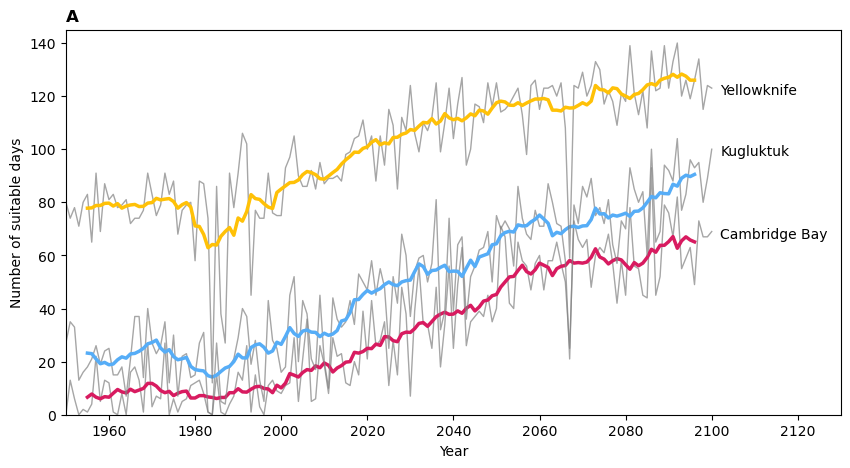

In [38]:
# Define colours
colors = {
    "Cambridge Bay": "#D81B60",
    "Kugluktuk": "#56ADF7",
    "Yellowknife": "#FFC107"
}

fig, ax = plt.subplots(figsize=(10, 5))

#  Panel A: Number of suitable days over time at the three locations ----

for lat, lon, name in zip(lats, lons, ["Cambridge Bay", "Kugluktuk", "Yellowknife"]):
    series = ssp245_locations_low.sortby("lat").sortby("lon").sel(
        lat=lat, lon=lon, method="nearest"
    )
    
    x = series["year"]
    y = series["n_days"]
    
    # Yearly mean summer temperature
    ax.plot(x, y,  color="grey", linewidth=1, alpha=0.7)

    # 10-year rolling mean
    y_roll = y.rolling(year = 10, center = True).mean()

    ax.plot(
        x,
        y_roll,
        color = colors[name],
        linewidth = 2.5,
        label = name
    )
    
    # Add label at the end of the line
    ax.text(
        x.values[-1] + 2,     # last year
        y[-1] - 1,            # last value
        name,
        color= 'black',
        fontsize=10,
        va="center"
    )

ax.set_xlim(x.min(), x.max() + 30)
ax.set_ylim(0, 145)

ax.set_xlabel("Year")
ax.set_ylabel("Number of suitable days")

ax.set_title("A", loc="left", fontweight="bold")

plt.show()

plot a graph showing the first and last day of suitability (median and IQR)

Text(0.0, 1.0, 'B')

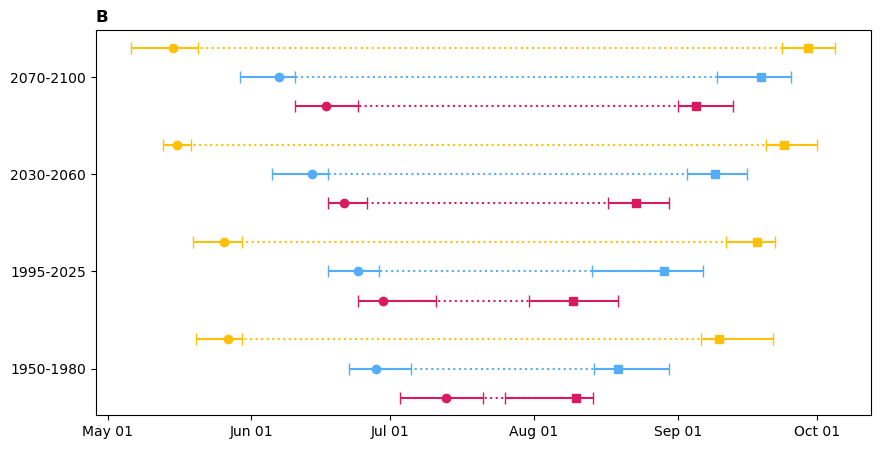

In [31]:
# Define time periods
periods = {
    "1950-1980": slice(1950, 1980),
    "1995-2025": slice(1995, 2025),
    "2030-2060": slice(2030, 2060),
    "2070-2100": slice(2070, 2100)
}

# Define locations
locations = {
    "Cambridge Bay": (lats[0], lons[0]),
    "Kugluktuk": (lats[1], lons[1]),
    "Yellowknife": (lats[2], lons[2])
}

# Define colours
colors = {
    "Cambridge Bay": "#D81B60",
    "Kugluktuk": "#56ADF7",
    "Yellowknife": "#FFC107"
}

fig, ax = plt.subplots(figsize=(10, 5))

# Panel B: Start and end date of suitability ----
offsets = {
    "Cambridge Bay": -0.3,
    "Kugluktuk": 0.0,
    "Yellowknife": 0.3
}

for i, (period_name, yrs) in enumerate(periods.items()):

    for loc_name, (lat, lon) in locations.items():

        ds = ssp245_locations_low.sel(
            lat=lat,
            lon=lon,
            method="nearest"
        ).sel(year=yrs)

        
        # First day
        start = ds.first_day

        start_median = start.median("year").item()
        start_q25 = start.quantile(0.25, dim="year").item()
        start_q75 = start.quantile(0.75, dim="year").item()

        start_err = [
            [start_median - start_q25],
            [start_q75 - start_median]
        ]

        ax.errorbar(
            start_median,
            i + offsets[loc_name],
            xerr=start_err,
            fmt='o',
            color=colors[loc_name],
            capsize=4,
            label=loc_name if i == 0 else ""
        )

        # Last day
        end = ds.last_day

        end_median = end.median("year").item()
        end_q25 = end.quantile(0.25, dim="year").item()
        end_q75 = end.quantile(0.75, dim="year").item()

        end_err = [
            [end_median - end_q25],
            [end_q75 - end_median]
        ]

        ax.errorbar(
            end_median,
            i + offsets[loc_name],
            xerr=end_err,
            fmt='s',
            color=colors[loc_name],
            capsize=4
        )

        # Connect start and end dates
        ax.plot(
            [start_median, end_median],
            [i + offsets[loc_name], i + offsets[loc_name]],
            linestyle=":",
            color=colors[loc_name],
            linewidth=1.5,
            zorder=0
        )
        
# y-axis labels
period_labels = list(periods.keys())

ax.set_yticks(range(len(periods)))
ax.set_yticklabels(period_labels)

# Convert x axis from date of year to readable format
tick_days = [121, 152, 182, 213, 244, 274]

tick_labels = [
    (dt.datetime(2001, 1, 1) + dt.timedelta(days=d-1)).strftime("%b %d")
    for d in tick_days
]

ax.set_xticks(tick_days)
ax.set_xticklabels(tick_labels)

ax.set_title("B", loc="left", fontweight="bold")

Look at the mean summer temperature (Jul and Aug) of the three locations

In [32]:
summer_list = []

for year in range(1950, 2101):
    print(f"Processing year {year}...")
    
    ds = xr.open_dataset(
        f"data-raw/climate-data/ssp245/tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    )

    # Keep only the three locations
    ds = ds.sel(lat=lats, lon=lons, method="nearest")

    # July-August
    ds = ds.sel(time=ds.time.dt.month.isin([7, 8]))

    # Mean summer temperature for this year
    summer = ds["tas"].mean("time")

    # Give it a year dimension
    summer = summer.expand_dims(year=[year])

    summer_list.append(summer)

    ds.close()

summer_mean = xr.concat(summer_list, dim="year")

Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...
Processing year 1981...
Processing year 1982...
Processing year 1983...
Processing year 1984...
Processing year 1985...
Processing year 1986...
Processing year 1987...
Processing year 1988...
Processing year 1989...
Processing year 1990...
Processing year 

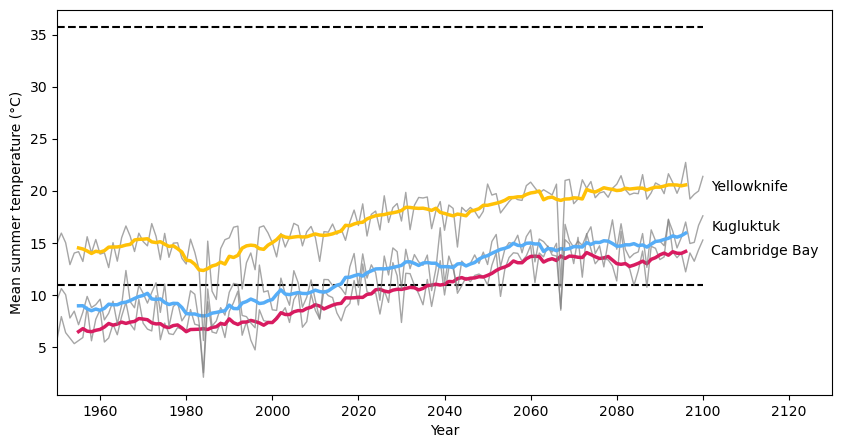

In [33]:
# Define colours
colors = {
    "Cambridge Bay": "#D81B60",
    "Kugluktuk": "#56ADF7",
    "Yellowknife": "#FFC107"
}

#  Panel C: Mean summer temperature
fig, ax = plt.subplots(figsize=(10, 5))

# Horizontal dotted line indicating the minimum and maximum thermal limits for transmission
plt.hlines(xmin = 1950, xmax = 2100, y = temp_min_lower, color='black', linestyle='--') # temp_min_lower from the start of the script
plt.hlines(xmin = 1950, xmax = 2100, y = temp_max_lower, color='black', linestyle='--')
#plt.fill_between(range(1950,2101), 10.8, 35.8, color='lightgray', alpha = 0.4) 

for lat, lon, name in zip(lats, lons, ["Cambridge Bay", "Kugluktuk", "Yellowknife"]):
    series = summer_mean.sortby("lat").sortby("lon").sel(
        lat=lat, lon=lon, method="nearest"
    )
    
    x = series["year"]
    y = series

    # Yearly mean summer temperature
    ax.plot(x, y,  color="grey", linewidth=1, alpha=0.7)

    # 10-year rolling mean
    y_roll = y.rolling(year = 10, center = True).mean()

    ax.plot(
        x,
        y_roll,
        color=colors[name],
        linewidth=2.5,
        label=name
    )
    	
    # Add label at the end of the line
    ax.text(
        x.values[-1] + 2,     # last year
        y.values[-1] - 1,     # last value
        name,
        color= 'black',
        fontsize=10,
        va="center"
    )

ax.set_xlim(1950, 2130)
ax.set_xlabel("Year")
ax.set_ylabel("Mean summer temperature (°C)")
plt.show()

Put the three panels together

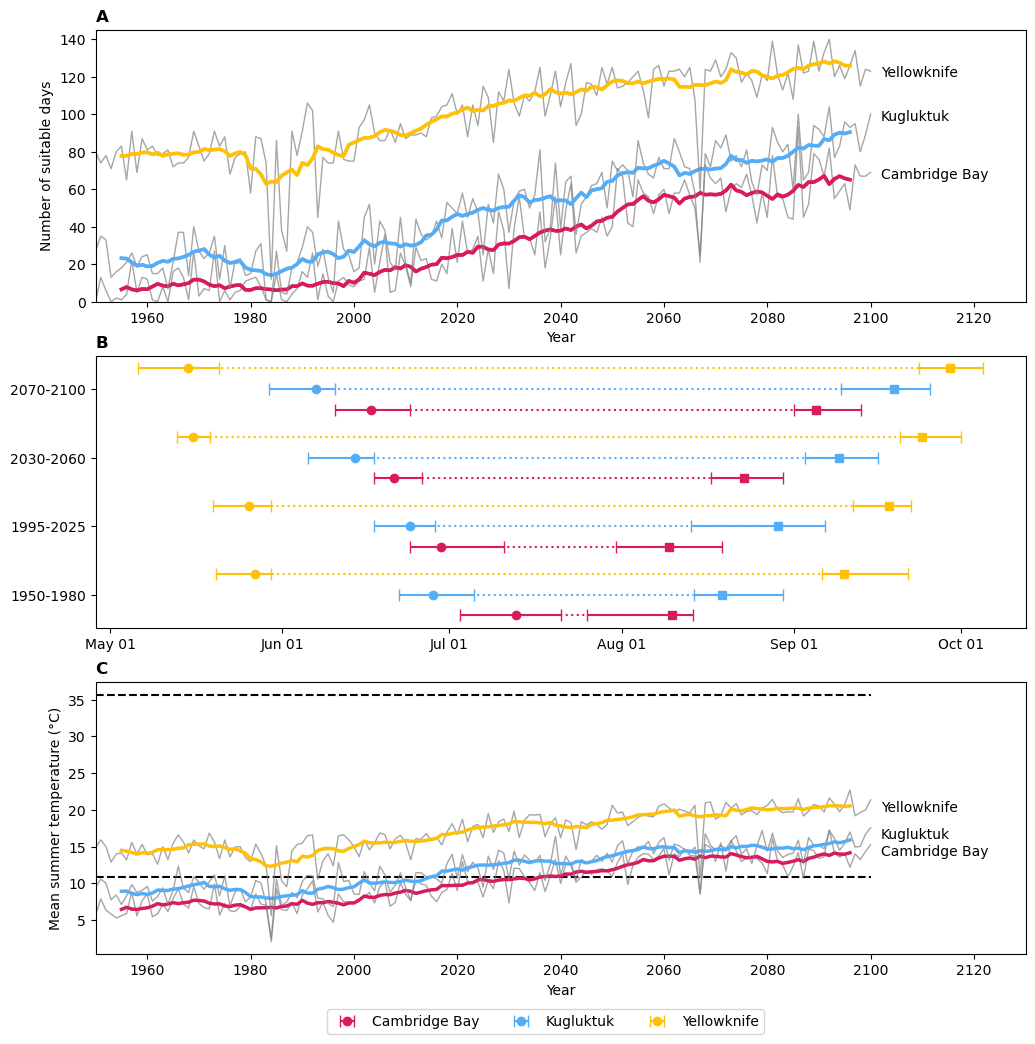

In [39]:
# Define time periods
periods = {
    "1950-1980": slice(1950, 1980),
    "1995-2025": slice(1995, 2025),
    "2030-2060": slice(2030, 2060),
    "2070-2100": slice(2070, 2100)
}

# Define locations
locations = {
    "Cambridge Bay": (lats[0], lons[0]),
    "Kugluktuk": (lats[1], lons[1]),
    "Yellowknife": (lats[2], lons[2])
}

# Define colours
colors = {
    "Cambridge Bay": "#D81B60",
    "Kugluktuk": "#56ADF7",
    "Yellowknife": "#FFC107"
}

fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize = (12,12))

#  Panel A: Number of suitable days over time at the three locations ----

for lat, lon, name in zip(lats, lons, ["Cambridge Bay", "Kugluktuk", "Yellowknife"]):
    series = ssp245_locations_low.sortby("lat").sortby("lon").sel(
        lat=lat, lon=lon, method="nearest"
    )
    
    x = series["year"]
    y = series["n_days"]
    
    # Yearly mean summer temperature
    axes[0].plot(x, y,  color="grey", linewidth=1, alpha=0.7)

    # 10-year rolling mean
    y_roll = y.rolling(year = 10, center = True).mean()

    axes[0].plot(
        x,
        y_roll,
        color = colors[name],
        linewidth = 2.5,
        label = name
    )

    axes[0].plot(
        x,
        y_roll,
        color = colors[name],
        linewidth = 2.5,
        label = name
    )
    # Add label at the end of the line
    axes[0].text(
        x.values[-1] + 2,     # last year
        y[-1] - 1,            # last value
        name,
        color= 'black',
        fontsize=10,
        va="center"
    )

axes[0].set_xlim(x.min(), x.max() + 30)
axes[0].set_ylim(0, 145)

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of suitable days")

axes[0].set_title("A", loc="left", fontweight="bold")


# Panel B: Start and end date of suitability ----
offsets = {
    "Cambridge Bay": -0.3,
    "Kugluktuk": 0.0,
    "Yellowknife": 0.3
}

for i, (period_name, yrs) in enumerate(periods.items()):

    for loc_name, (lat, lon) in locations.items():

        ds = ssp245_locations_low.sel(
            lat=lat,
            lon=lon,
            method="nearest"
        ).sel(year=yrs)

        
        # First day
        start = ds.first_day

        start_median = start.median("year").item()
        start_q25 = start.quantile(0.25, dim="year").item()
        start_q75 = start.quantile(0.75, dim="year").item()

        start_err = [
            [start_median - start_q25],
            [start_q75 - start_median]
        ]

        axes[1].errorbar(
            start_median,
            i + offsets[loc_name],
            xerr=start_err,
            fmt='o',
            color=colors[loc_name],
            capsize=4,
            label=loc_name if i == 0 else ""
        )

        # Last day
        end = ds.last_day

        end_median = end.median("year").item()
        end_q25 = end.quantile(0.25, dim="year").item()
        end_q75 = end.quantile(0.75, dim="year").item()

        end_err = [
            [end_median - end_q25],
            [end_q75 - end_median]
        ]

        axes[1].errorbar(
            end_median,
            i + offsets[loc_name],
            xerr=end_err,
            fmt='s',
            color=colors[loc_name],
            capsize=4
        )

        # Connect start and end dates
        axes[1].plot(
            [start_median, end_median],
            [i + offsets[loc_name], i + offsets[loc_name]],
            linestyle=":",
            color=colors[loc_name],
            linewidth=1.5,
            zorder=0
        )
        
# y-axis labels
period_labels = list(periods.keys())

axes[1].set_yticks(range(len(periods)))
axes[1].set_yticklabels(period_labels)

# Convert x axis from date of year to readable format
tick_days = [121, 152, 182, 213, 244, 274]

tick_labels = [
    (dt.datetime(2001, 1, 1) + dt.timedelta(days=d-1)).strftime("%b %d")
    for d in tick_days
]

axes[1].set_xticks(tick_days)
axes[1].set_xticklabels(tick_labels)

axes[1].set_title("B", loc="left", fontweight="bold")


#  Panel C: Mean summer temperature

# Horizontal dotted line indicating the minimum and maximum thermal limits for transmission
plt.hlines(xmin = 1950, xmax = 2100, y = temp_min_lower, color='black', linestyle='--') # temp_min_lower from the start of the script
plt.hlines(xmin = 1950, xmax = 2100, y = temp_max_lower, color='black', linestyle='--')
#plt.fill_between(range(1950,2101), 10.8, 35.8, color='lightgray', alpha = 0.4) 

for lat, lon, name in zip(lats, lons, ["Cambridge Bay", "Kugluktuk", "Yellowknife"]):
    series = summer_mean.sortby("lat").sortby("lon").sel(
        lat=lat, lon=lon, method="nearest"
    )
    
    x = series["year"]
    y = series

    # Yearly mean summer temperature
    axes[2].plot(x, y,  color="grey", linewidth=1, alpha=0.7)

    # 10-year rolling mean
    y_roll = y.rolling(year = 10, center = True).mean()

    axes[2].plot(
        x,
        y_roll,
        color=colors[name],
        linewidth=2.5,
        label=name
    )
    	
    # Add label at the end of the line
    axes[2].text(
        x.values[-1] + 2,     # last year
        y.values[-1] - 1,     # last value
        name,
        color= 'black',
        fontsize=10,
        va="center"
    )

axes[2].set_xlim(1950, 2130)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Mean summer temperature (°C)")
axes[2].set_title("C", loc="left", fontweight="bold")

# Shared legend
handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.07)
)

plt.savefig("figures/FigS9-locations_upperCI.png", dpi=300, bbox_inches="tight")

plt.show()